In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

# Загружаем данные
df = pd.read_csv('/Users/sofya/Desktop/diplomahse/ozon_train.csv')
print("Строк, колонок:", df.shape)
print("\nДоля контрафакта:")
print(df['resolution'].value_counts(normalize=True))
print("\nФинтех-колонки есть?")
print([c for c in df.columns if any(x in c for x in ['return', 'sales', 'seller', 'time', 'Gmv'])])

Строк, колонок: (197198, 45)

Доля контрафакта:
resolution
0    0.933813
1    0.066187
Name: proportion, dtype: float64

Финтех-колонки есть?
['item_time_alive', 'item_count_fake_returns7', 'item_count_fake_returns30', 'item_count_fake_returns90', 'item_count_sales7', 'item_count_sales30', 'item_count_sales90', 'item_count_returns7', 'item_count_returns30', 'item_count_returns90', 'GmvTotal7', 'GmvTotal30', 'GmvTotal90', 'seller_time_alive']


In [2]:
from sklearn.model_selection import train_test_split


def make_seller_split(df, seller_col='SellerID', target_col='resolution', random_state=42):
    sellers = df[seller_col].drop_duplicates()

    train_sellers, temp_sellers = train_test_split(
        sellers,
        test_size=0.30,
        random_state=random_state,
        shuffle=True,
    )
    val_sellers, test_sellers = train_test_split(
        temp_sellers,
        test_size=0.50,
        random_state=random_state,
        shuffle=True,
    )

    train_df = df[df[seller_col].isin(train_sellers)].copy()
    val_df = df[df[seller_col].isin(val_sellers)].copy()
    test_df = df[df[seller_col].isin(test_sellers)].copy()

    train_ids = set(train_df[seller_col].unique())
    val_ids = set(val_df[seller_col].unique())
    test_ids = set(test_df[seller_col].unique())

    assert train_ids.isdisjoint(val_ids)
    assert train_ids.isdisjoint(test_ids)
    assert val_ids.isdisjoint(test_ids)

    for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
        print(f'{name}: {part.shape}, positive_rate={part[target_col].mean():.4f}')

    return train_df, val_df, test_df


train_df, val_df, test_df = make_seller_split(df)

train: (135626, 45), positive_rate=0.0687
val: (27156, 45), positive_rate=0.0622
test: (34416, 45), positive_rate=0.0593


In [3]:
def add_fintech_features(df):
    df = df.copy()
    df['return_rate_30'] = df['item_count_returns30'] / (df['item_count_sales30'] + 1)
    df['fake_return_rate_30'] = df['item_count_fake_returns30'] / (df['item_count_sales30'] + 1)
    df['fake_return_rate_90'] = df['item_count_fake_returns90'] / (df['item_count_sales90'] + 1)
    df['seller_velocity'] = df['item_count_sales30'] / (df['seller_time_alive'] + 1)
    df['gmv_per_day'] = df['GmvTotal30'] / (df['item_time_alive'] + 1)
    df['both_new'] = ((df['item_time_alive'] < 30) & (df['seller_time_alive'] < 90)).astype(int)
    return df

train_df = add_fintech_features(train_df)
test_df = add_fintech_features(test_df)

# Графовые агрегаты только по train — без leakage
seller_stats = train_df.groupby('SellerID').agg(
    seller_item_count=('ItemID', 'count'),
    seller_avg_return_rate=('return_rate_30', 'mean'),
    seller_avg_fake_returns=('fake_return_rate_30', 'mean'),
).reset_index()

train_df = train_df.merge(seller_stats, on='SellerID', how='left')
test_df = test_df.merge(seller_stats, on='SellerID', how='left')
test_df[['seller_item_count','seller_avg_return_rate','seller_avg_fake_returns']] = \
    test_df[['seller_item_count','seller_avg_return_rate','seller_avg_fake_returns']].fillna(0)

print("Фич итого:", train_df.shape[1])
print(train_df[['return_rate_30','fake_return_rate_30','seller_velocity','both_new']].describe().round(3))

Фич итого: 54
       return_rate_30  fake_return_rate_30  seller_velocity    both_new
count      135626.000           135626.000       135626.000  135626.000
mean            0.005                0.002            0.008       0.106
std             0.045                0.026            0.163       0.308
min             0.000                0.000            0.000       0.000
25%             0.000                0.000            0.000       0.000
50%             0.000                0.000            0.000       0.000
75%             0.000                0.000            0.000       0.000
max             2.000                2.000           31.240       1.000


In [4]:
missing = [name for name in ['train_df', 'test_df'] if name not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first. Missing variables: {missing}")

feature_cols = [c for c in train_df.columns if c not in ['resolution', 'ItemID', 'SellerID']]
X_train = train_df[feature_cols].copy()
y_train = train_df['resolution'].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df['resolution'].copy()

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('Object columns:', X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist())

X_train: (135626, 51)
X_test: (34416, 51)
Object columns: ['brand_name', 'description', 'name_rus', 'CommercialTypeName4']


In [5]:
from sklearn.model_selection import GroupShuffleSplit

missing = [name for name in ['X_train', 'y_train', 'X_test', 'y_test', 'train_df', 'test_df'] if name not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first. Missing variables: {missing}")

if 'SellerID' in X_train.columns:
    seller_id_train = X_train['SellerID']
    seller_id_test = X_test['SellerID']
else:
    print("Warning: SellerID is not in X_train, so GroupShuffleSplit will use SellerID from train_df/test_df.")
    seller_id_train = train_df.loc[X_train.index, 'SellerID']
    seller_id_test = test_df.loc[X_test.index, 'SellerID']

groups = seller_id_train
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(gss.split(X_train, y_train, groups=groups))

X_tr = X_train.iloc[train_idx].copy()
y_tr = y_train.iloc[train_idx].copy()
X_val = X_train.iloc[val_idx].copy()
y_val = y_train.iloc[val_idx].copy()
X_test = X_test.copy()

X_tr['SellerID'] = seller_id_train.iloc[train_idx].values
X_val['SellerID'] = seller_id_train.iloc[val_idx].values
X_test['SellerID'] = seller_id_test.values

assert len(set(X_tr['SellerID']) & set(X_val['SellerID'])) == 0
assert len(set(X_tr['SellerID']) & set(X_test['SellerID'])) == 0
assert len(set(X_val['SellerID']) & set(X_test['SellerID'])) == 0

print(f"Train: {len(X_tr)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Train positive rate: {y_tr.mean():.4f}")
print(f"Val positive rate: {y_val.mean():.4f}")
print(f"Test positive rate: {y_test.mean():.4f}")

Train: 110970, Val: 24656, Test: 34416
Train positive rate: 0.0651
Val positive rate: 0.0850
Test positive rate: 0.0593


In [6]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

missing = [name for name in ['X_tr', 'y_tr', 'X_val', 'y_val', 'X_test', 'y_test'] if name not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first. Missing variables: {missing}")

cat_features = X_tr.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if 'SellerID' in X_tr.columns and 'SellerID' not in cat_features:
    cat_features.append('SellerID')

for col in cat_features:
    X_tr[col] = X_tr[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print('Categorical features:', cat_features)
results = []

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=len(y_tr[y_tr == 0]) / len(y_tr[y_tr == 1]),
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
)

model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_val, y_val))

val_proba = model.predict_proba(X_val)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, test_proba)
pr_auc = average_precision_score(y_test, test_proba)
precision, recall, thresholds = precision_recall_curve(y_test, test_proba)
mask = precision >= 0.9
recall_at_p90 = recall[mask].max() if mask.any() else 0.0

print(f"E0 | threshold=0.5 | ROC-AUC={roc_auc:.4f} | PR-AUC={pr_auc:.4f} | Recall@P≥0.9={recall_at_p90:.4f}")

results.append({
    'experiment': 'E0_baseline',
    'threshold': 0.5,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'recall_at_p90': recall_at_p90,
})

Categorical features: ['brand_name', 'description', 'name_rus', 'CommercialTypeName4', 'SellerID']
0:	test: 0.8934379	best: 0.8934379 (0)	total: 104ms	remaining: 1m 43s
100:	test: 0.9625310	best: 0.9627114 (99)	total: 3.29s	remaining: 29.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9627195705
bestIteration = 106

Shrink model to first 107 iterations.
E0 | threshold=0.5 | ROC-AUC=0.9116 | PR-AUC=0.6421 | Recall@P≥0.9=0.2196


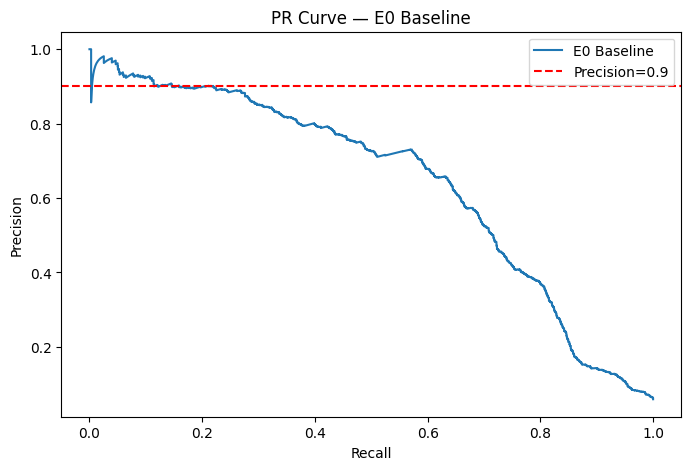

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

missing = [name for name in ['y_test', 'test_proba'] if name not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first. Missing variables: {missing}")

precision, recall, thresholds = precision_recall_curve(y_test, test_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label='E0 Baseline')
plt.axhline(y=0.9, color='red', linestyle='--', label='Precision=0.9')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.title('PR Curve — E0 Baseline')
plt.savefig('pr_curve_e0.png', dpi=150, bbox_inches='tight')
plt.show()

=== E1 ===
Best threshold: 0.975285
Validation Precision@best_t: 0.921212
Validation Recall@best_t: 0.072554
Test Precision@best_t: 0.930851
Test Recall@best_t: 0.085784
ROC-AUC: 0.911635
PR-AUC: 0.642136


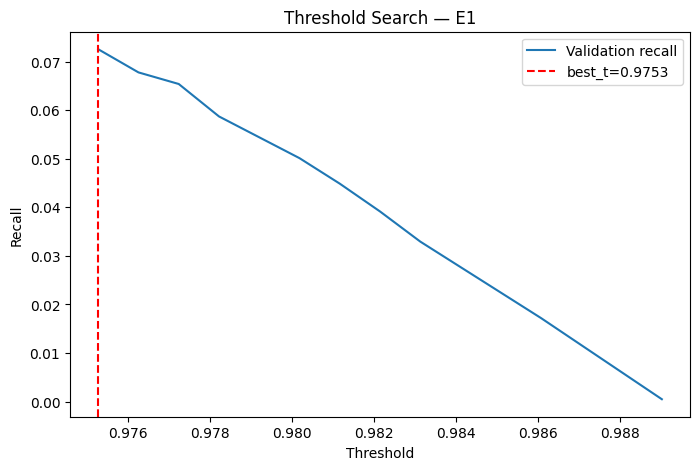

,experiment,threshold,roc_auc,pr_auc,precision_at_best_t,recall_at_best_t,val_precision_at_best_t,val_recall_at_best_t,recall_at_p90_test_threshold,notes
0,E1_threshold_optimization,0.975285,0.911635,0.642136,0.930851,0.085784,0.921212,0.072554,0.085784,"Threshold optimization on validation set, appl..."


,experiment,threshold,roc_auc,pr_auc,precision_at_05,recall_at_05,recall_at_p90_curve,precision_at_best_t,recall_at_best_t,val_precision_at_best_t,val_recall_at_best_t,recall_at_p90_test_threshold,notes,recall_at_p90_prcurve
0,E0_baseline_default_threshold,0.500000,0.911635,0.642136,0.313542,0.820588,0.219608,NaN,NaN,NaN,NaN,NaN,"Baseline CatBoost, threshold=0.5",0.219608
1,E2_undersampling_calibration,0.973323,0.916622,0.648021,NaN,NaN,NaN,0.900000,0.119118,0.904564,0.258294,0.119118,RandomUnderSampler on train only + Dal Pozzolo...,0.172549
2,E3_deviation_features,0.976266,0.918986,0.652982,NaN,NaN,NaN,0.936709,0.072549,0.904255,0.201422,0.072549,Deviation features from train-only seller medi...,0.122549
3,E1_threshold_optimization,0.975285,0.911635,0.642136,NaN,NaN,NaN,0.930851,0.085784,0.921212,0.072554,0.085784,"Threshold optimization on validation set, appl...",NaN


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, roc_auc_score, average_precision_score

missing = [name for name in ['model', 'X_val', 'y_val', 'X_test', 'y_test'] if name not in globals()]
if missing:
    raise RuntimeError(f"Run E0 first. Missing variables: {missing}")

if 'val_proba' not in globals():
    val_proba = model.predict_proba(X_val)[:, 1]

if 'test_proba' not in globals():
    test_proba = model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 1000)

val_precision_list = []
val_recall_list = []

best_t = 0.5
best_recall = 0.0
found_valid_threshold = False

for t in thresholds:
    preds = (val_proba >= t).astype(int)
    p = precision_score(y_val, preds, zero_division=0)
    r = recall_score(y_val, preds, zero_division=0)

    val_precision_list.append(p)
    val_recall_list.append(r)

    if p >= 0.9:
        found_valid_threshold = True
        if r > best_recall:
            best_recall = r
            best_t = t

if not found_valid_threshold:
    print("No threshold on validation set achieves precision >= 0.9. Using default best_t=0.5.")

val_pred_best_t = (val_proba >= best_t).astype(int)
val_precision_at_best_t = precision_score(y_val, val_pred_best_t, zero_division=0)
val_recall_at_best_t = recall_score(y_val, val_pred_best_t, zero_division=0)

test_pred_e1 = (test_proba >= best_t).astype(int)

roc_auc_e1 = roc_auc_score(y_test, test_proba)
pr_auc_e1 = average_precision_score(y_test, test_proba)
precision_at_best_t = precision_score(y_test, test_pred_e1, zero_division=0)
recall_at_best_t = recall_score(y_test, test_pred_e1, zero_division=0)
recall_at_p90_test_threshold = recall_at_best_t

print("=== E1 ===")
print(f"Best threshold: {best_t:.6f}")
print(f"Validation Precision@best_t: {val_precision_at_best_t:.6f}")
print(f"Validation Recall@best_t: {val_recall_at_best_t:.6f}")
print(f"Test Precision@best_t: {precision_at_best_t:.6f}")
print(f"Test Recall@best_t: {recall_at_best_t:.6f}")
print(f"ROC-AUC: {roc_auc_e1:.6f}")
print(f"PR-AUC: {pr_auc_e1:.6f}")

valid_mask = np.array(val_precision_list) >= 0.9

plt.figure(figsize=(8, 5))
if valid_mask.any():
    plt.plot(thresholds[valid_mask], np.array(val_recall_list)[valid_mask], label='Validation recall')
    plt.axvline(best_t, color='red', linestyle='--', label=f'best_t={best_t:.4f}')
    plt.xlabel('Threshold')
    plt.ylabel('Recall')
    plt.title('Threshold Search — E1')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'No threshold with validation precision >= 0.9', ha='center', va='center')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title('Threshold Search — E1')

plt.savefig('threshold_search_e1.png', dpi=150, bbox_inches='tight')
plt.show()

results_row_e1 = pd.DataFrame([{
    "experiment": "E1_threshold_optimization",
    "threshold": best_t,
    "roc_auc": roc_auc_e1,
    "pr_auc": pr_auc_e1,
    "precision_at_best_t": precision_at_best_t,
    "recall_at_best_t": recall_at_best_t,
    "val_precision_at_best_t": val_precision_at_best_t,
    "val_recall_at_best_t": val_recall_at_best_t,
    "recall_at_p90_test_threshold": recall_at_p90_test_threshold,
    "notes": "Threshold optimization on validation set, applied once to test"
}])

results_path = Path("results_table.csv")
if results_path.exists():
    results_table = pd.read_csv(results_path)
else:
    results_table = pd.DataFrame()

results_table = results_table[results_table["experiment"] != "E1_threshold_optimization"] if not results_table.empty and "experiment" in results_table.columns else results_table
results_table = pd.concat([results_table, results_row_e1], ignore_index=True)
results_table.to_csv(results_path, index=False)

display(results_row_e1)
display(results_table)

In [9]:
import pandas as pd

if 'results' not in globals():
    raise RuntimeError("Run previous experiment cells first. Missing variable: results")

results_df = pd.DataFrame(results)
results_df.to_csv('results_table.csv', index=False)
display(results_df)

,experiment,threshold,roc_auc,pr_auc,recall_at_p90
0,E0_baseline,0.5,0.911635,0.642136,0.219608


In [10]:
from sklearn.metrics import precision_score, recall_score

test_pred_05 = (test_proba >= 0.5).astype(int)
precision_at_05 = precision_score(y_test, test_pred_05, zero_division=0)
recall_at_05 = recall_score(y_test, test_pred_05, zero_division=0)
recall_at_p90_curve = recall_at_p90 if 'recall_at_p90' in globals() else 0.0

results_row = pd.DataFrame([{
    "experiment": "E0_baseline_default_threshold",
    "threshold": 0.5,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "precision_at_05": precision_at_05,
    "recall_at_05": recall_at_05,
    "recall_at_p90_curve": recall_at_p90_curve,
    "notes": "Baseline CatBoost, threshold=0.5"
}])

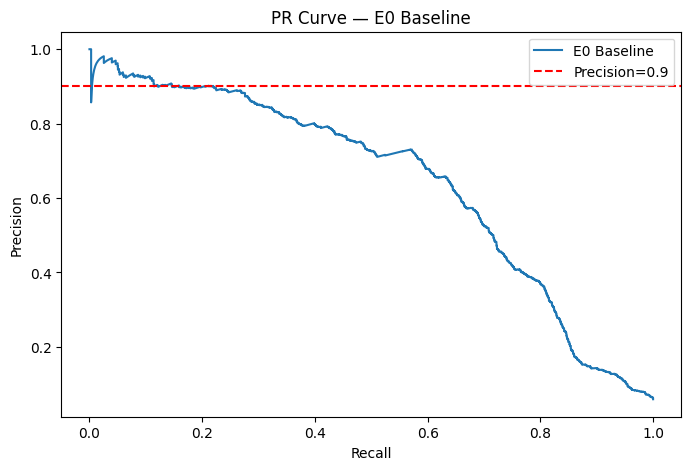

=== E0 FINAL ===
ROC-AUC: 0.9116346622043925
PR-AUC: 0.6421359154850766
Precision@0.5: 0.3135418617718674
Recall@0.5: 0.8205882352941176
Recall@Precision>=0.9: 0.2196078431372549
results_table.csv rows: 1
pr_curve_e0.png saved: True


In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, precision_recall_curve

missing = [name for name in ['y_test', 'test_proba', 'roc_auc', 'pr_auc'] if name not in globals()]
if missing:
    raise RuntimeError(f"Run E0 cells first. Missing variables: {missing}")

test_pred_05 = (test_proba >= 0.5).astype(int)
precision_at_05 = precision_score(y_test, test_pred_05, zero_division=0)
recall_at_05 = recall_score(y_test, test_pred_05, zero_division=0)

precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_test, test_proba)
recall_at_p90_curve = recall_at_p90_curve if 'recall_at_p90_curve' in globals() else recall_curve[precision_curve >= 0.9].max() if (precision_curve >= 0.9).any() else 0.0

results_row = pd.DataFrame([{
    'experiment': 'E0_baseline_default_threshold',
    'threshold': 0.5,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'precision_at_05': precision_at_05,
    'recall_at_05': recall_at_05,
    'recall_at_p90_curve': recall_at_p90_curve,
    'notes': 'Baseline CatBoost, threshold=0.5',
}])

results_path = Path('results_table.csv')
if results_path.exists():
    results_path.unlink()
results_row.to_csv(results_path, index=False)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, label='E0 Baseline')
plt.axhline(y=0.9, color='red', linestyle='--', label='Precision=0.9')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve — E0 Baseline')
plt.legend()
plt.savefig('pr_curve_e0.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== E0 FINAL ===')
print(f'ROC-AUC: {roc_auc}')
print(f'PR-AUC: {pr_auc}')
print(f'Precision@0.5: {precision_at_05}')
print(f'Recall@0.5: {recall_at_05}')
print(f'Recall@Precision>=0.9: {recall_at_p90_curve}')
print(f'results_table.csv rows: {len(pd.read_csv(results_path))}')
print(f'pr_curve_e0.png saved: {Path("pr_curve_e0.png").exists()}')

In [12]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import precision_score, recall_score, precision_recall_curve

required = [
    'y_test',
    'test_proba',
    'y_val',
    'val_proba',
    'roc_auc',
    'pr_auc',
    'best_t',
    'roc_auc_e1',
    'pr_auc_e1',
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run completed E0/E1 cells first. Missing variables: {missing}")

# Reuse existing E0/E1 outputs and only rebuild final artifacts.
precision_at_05_final = globals().get('precision_at_05')
recall_at_05_final = globals().get('recall_at_05')
recall_at_p90_curve_final = globals().get('recall_at_p90_curve')

if precision_at_05_final is None or recall_at_05_final is None:
    test_pred_05_final = (test_proba >= 0.5).astype(int)
    precision_at_05_final = precision_score(y_test, test_pred_05_final, zero_division=0)
    recall_at_05_final = recall_score(y_test, test_pred_05_final, zero_division=0)

if recall_at_p90_curve_final is None:
    precision_curve_final, recall_curve_final, _ = precision_recall_curve(y_test, test_proba)
    recall_at_p90_curve_final = (
        recall_curve_final[precision_curve_final >= 0.9].max()
        if (precision_curve_final >= 0.9).any()
        else 0.0
    )

val_precision_at_best_t_final = globals().get('val_precision_at_best_t')
val_recall_at_best_t_final = globals().get('val_recall_at_best_t')
precision_at_best_t_final = globals().get('precision_at_best_t')
recall_at_best_t_final = globals().get('recall_at_best_t')

if val_precision_at_best_t_final is None or val_recall_at_best_t_final is None:
    val_pred_best_t_final = (val_proba >= best_t).astype(int)
    val_precision_at_best_t_final = precision_score(y_val, val_pred_best_t_final, zero_division=0)
    val_recall_at_best_t_final = recall_score(y_val, val_pred_best_t_final, zero_division=0)

if precision_at_best_t_final is None or recall_at_best_t_final is None:
    test_pred_best_t_final = (test_proba >= best_t).astype(int)
    precision_at_best_t_final = precision_score(y_test, test_pred_best_t_final, zero_division=0)
    recall_at_best_t_final = recall_score(y_test, test_pred_best_t_final, zero_division=0)

e0_row_final = {
    'experiment': 'E0_baseline_default_threshold',
    'threshold': 0.5,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'precision_at_05': precision_at_05_final,
    'recall_at_05': recall_at_05_final,
    'recall_at_p90_curve': recall_at_p90_curve_final,
    'precision_at_best_t': pd.NA,
    'recall_at_best_t': pd.NA,
    'val_precision_at_best_t': pd.NA,
    'val_recall_at_best_t': pd.NA,
    'recall_at_p90_test_threshold': pd.NA,
    'notes': 'Baseline CatBoost, threshold=0.5',
}

e1_row_final = {
    'experiment': 'E1_threshold_optimization',
    'threshold': best_t,
    'roc_auc': roc_auc_e1,
    'pr_auc': pr_auc_e1,
    'precision_at_05': pd.NA,
    'recall_at_05': pd.NA,
    'recall_at_p90_curve': pd.NA,
    'precision_at_best_t': precision_at_best_t_final,
    'recall_at_best_t': recall_at_best_t_final,
    'val_precision_at_best_t': val_precision_at_best_t_final,
    'val_recall_at_best_t': val_recall_at_best_t_final,
    'recall_at_p90_test_threshold': recall_at_best_t_final,
    'notes': 'Threshold optimization on validation set, applied once to test',
}

results_table_final = pd.DataFrame([e0_row_final, e1_row_final])
results_table_final = results_table_final.drop_duplicates(subset=['experiment'], keep='last')
results_table_final = results_table_final.sort_values('experiment').reset_index(drop=True)

results_path = Path('results_table.csv')
results_table_final.to_csv(results_path, index=False)

experiments_final = results_table_final['experiment'].tolist()
pr_curve_exists = Path('pr_curve_e0.png').exists()
threshold_curve_exists = Path('threshold_search_e1.png').exists()

print('=== FINAL ARTIFACT CHECK ===')
print(f'results_table.csv rows: {len(results_table_final)}')
print(f'experiments: {experiments_final}')
print(f'pr_curve_e0.png exists: {pr_curve_exists}')
print(f'threshold_search_e1.png exists: {threshold_curve_exists}')

display(results_table_final)

=== FINAL ARTIFACT CHECK ===
results_table.csv rows: 2
experiments: ['E0_baseline_default_threshold', 'E1_threshold_optimization']
pr_curve_e0.png exists: True
threshold_search_e1.png exists: True


,experiment,threshold,roc_auc,pr_auc,precision_at_05,recall_at_05,recall_at_p90_curve,precision_at_best_t,recall_at_best_t,val_precision_at_best_t,val_recall_at_best_t,recall_at_p90_test_threshold,notes
0,E0_baseline_default_threshold,0.500000,0.911635,0.642136,0.313542,0.820588,0.219608,<NA>,<NA>,<NA>,<NA>,<NA>,"Baseline CatBoost, threshold=0.5"
1,E1_threshold_optimization,0.975285,0.911635,0.642136,<NA>,<NA>,<NA>,0.930851,0.085784,0.921212,0.072554,0.085784,"Threshold optimization on validation set, appl..."


In [13]:
%pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


0:	test: 0.9065746	best: 0.9065746 (0)	total: 51.2ms	remaining: 51.1s
100:	test: 0.9454483	best: 0.9455297 (97)	total: 3.29s	remaining: 29.3s
200:	test: 0.9486433	best: 0.9491459 (185)	total: 7.34s	remaining: 29.2s
300:	test: 0.9521464	best: 0.9523874 (294)	total: 11.2s	remaining: 26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9524955394
bestIteration = 320

Shrink model to first 321 iterations.


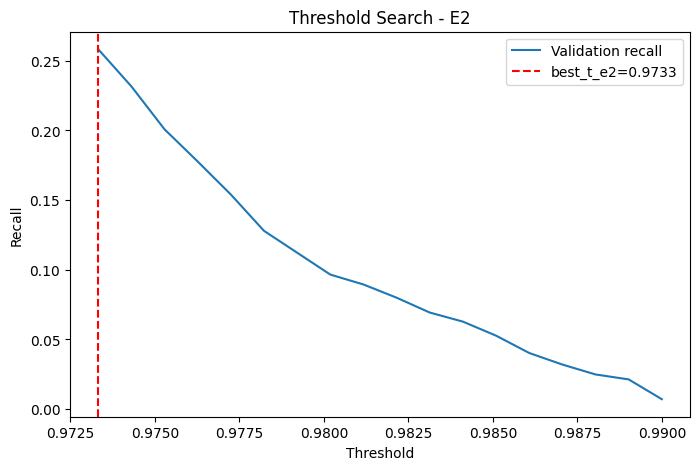

=== E2 ===
beta (original train prior): 0.068748
beta_res (undersampled train prior): 0.090909
best_t_e2: 0.973323
Validation Precision@best_t: 0.904564
Validation Recall@best_t: 0.258294
Test Precision@best_t: 0.900000
Test Recall@best_t: 0.119118
ROC-AUC: 0.916622
PR-AUC: 0.648021
threshold_search_e2.png exists: True


,experiment,threshold,roc_auc,pr_auc,precision_at_best_t,recall_at_best_t,val_precision_at_best_t,val_recall_at_best_t,recall_at_p90_test_threshold,notes
0,E2_undersampling_calibration,0.973323,0.916622,0.648021,0.9,0.119118,0.904564,0.258294,0.119118,RandomUnderSampler on train only + Dal Pozzolo...


In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import average_precision_score, precision_score, recall_score, roc_auc_score

missing = [name for name in ['train_df', 'val_df', 'test_df'] if name not in globals()]
if missing:
    raise RuntimeError(f"Run previous split cells first. Missing variables: {missing}")

results_path = Path('results_table.csv')
if not results_path.exists():
    raise RuntimeError('Run the final E0/E1 artifact fixation cell first: results_table.csv is missing.')

target_col = globals().get('target_col', 'resolution')
seller_stat_cols = ['seller_item_count', 'seller_avg_return_rate', 'seller_avg_fake_returns']


def add_same_fintech_features(df_part):
    if 'add_fintech_features' in globals():
        return add_fintech_features(df_part)

    df_part = df_part.copy()
    df_part['return_rate_30'] = df_part['item_count_returns30'] / (df_part['item_count_sales30'] + 1)
    df_part['fake_return_rate_30'] = df_part['item_count_fake_returns30'] / (df_part['item_count_sales30'] + 1)
    df_part['fake_return_rate_90'] = df_part['item_count_fake_returns90'] / (df_part['item_count_sales90'] + 1)
    df_part['seller_velocity'] = df_part['item_count_sales30'] / (df_part['seller_time_alive'] + 1)
    df_part['gmv_per_day'] = df_part['GmvTotal30'] / (df_part['item_time_alive'] + 1)
    df_part['both_new'] = ((df_part['item_time_alive'] < 30) & (df_part['seller_time_alive'] < 90)).astype(int)
    return df_part


train_base_e2 = add_same_fintech_features(train_df)
val_base_e2 = add_same_fintech_features(val_df)
test_base_e2 = add_same_fintech_features(test_df)

seller_stats_e2 = train_base_e2.groupby('SellerID').agg(
    seller_item_count=('ItemID', 'count'),
    seller_avg_return_rate=('return_rate_30', 'mean'),
    seller_avg_fake_returns=('fake_return_rate_30', 'mean'),
).reset_index()


def attach_train_only_seller_stats(df_part):
    df_part = df_part.copy()
    df_part = df_part.drop(columns=[c for c in seller_stat_cols if c in df_part.columns], errors='ignore')
    df_part = df_part.merge(seller_stats_e2, on='SellerID', how='left')
    df_part[seller_stat_cols] = df_part[seller_stat_cols].fillna(0)
    return df_part


train_df_e2 = attach_train_only_seller_stats(train_base_e2)
val_df_e2 = attach_train_only_seller_stats(val_base_e2)
test_df_e2 = attach_train_only_seller_stats(test_base_e2)

feature_cols_e2 = globals().get('feature_cols')
if feature_cols_e2 is None:
    feature_cols_e2 = [c for c in train_df_e2.columns if c not in [target_col, 'ItemID', 'SellerID']]

X_train = train_df_e2[feature_cols_e2].copy()
y_train = train_df_e2[target_col].copy()
X_val = val_df_e2[feature_cols_e2].copy()
y_val = val_df_e2[target_col].copy()
X_test = test_df_e2[feature_cols_e2].copy()
y_test = test_df_e2[target_col].copy()

# Match E0/E1 handling: SellerID is used as a categorical feature.
X_train['SellerID'] = train_df_e2['SellerID'].values
X_val['SellerID'] = val_df_e2['SellerID'].values
X_test['SellerID'] = test_df_e2['SellerID'].values

rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

beta = y_train.mean()
beta_res = y_train_res.mean()

cat_features_e2 = X_train_res.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if 'SellerID' in X_train_res.columns and 'SellerID' not in cat_features_e2:
    cat_features_e2.append('SellerID')

for col in cat_features_e2:
    X_train_res[col] = X_train_res[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

model_e2 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=len(y_train_res[y_train_res == 0]) / len(y_train_res[y_train_res == 1]),
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
)

model_e2.fit(X_train_res, y_train_res, cat_features=cat_features_e2, eval_set=(X_val, y_val))

val_proba_raw_e2 = model_e2.predict_proba(X_val)[:, 1]
test_proba_raw_e2 = model_e2.predict_proba(X_test)[:, 1]


def dal_pozzolo_calibrate(proba, beta, beta_res, eps=1e-15):
    proba = np.clip(proba, eps, 1 - eps)
    num = (beta / beta_res) * proba
    den = num + ((1 - beta) / (1 - beta_res)) * (1 - proba)
    return num / den


val_proba_cal_e2 = dal_pozzolo_calibrate(val_proba_raw_e2, beta=beta, beta_res=beta_res)
test_proba_cal_e2 = dal_pozzolo_calibrate(test_proba_raw_e2, beta=beta, beta_res=beta_res)

thresholds = np.linspace(0.01, 0.99, 1000)
val_precision_list_e2 = []
val_recall_list_e2 = []

best_t_e2 = 0.5
best_recall_e2 = -1.0
found_valid_threshold_e2 = False

for t in thresholds:
    val_pred_t = (val_proba_cal_e2 >= t).astype(int)
    p = precision_score(y_val, val_pred_t, zero_division=0)
    r = recall_score(y_val, val_pred_t, zero_division=0)

    val_precision_list_e2.append(p)
    val_recall_list_e2.append(r)

    if p >= 0.9:
        found_valid_threshold_e2 = True
        if r > best_recall_e2:
            best_recall_e2 = r
            best_t_e2 = t

if not found_valid_threshold_e2:
    print('No threshold on validation set achieves precision >= 0.9. Using default best_t_e2=0.5.')

val_pred_e2 = (val_proba_cal_e2 >= best_t_e2).astype(int)
test_pred_e2 = (test_proba_cal_e2 >= best_t_e2).astype(int)

val_precision_at_best_t_e2 = precision_score(y_val, val_pred_e2, zero_division=0)
val_recall_at_best_t_e2 = recall_score(y_val, val_pred_e2, zero_division=0)
precision_at_best_t_e2 = precision_score(y_test, test_pred_e2, zero_division=0)
recall_at_best_t_e2 = recall_score(y_test, test_pred_e2, zero_division=0)
roc_auc_e2 = roc_auc_score(y_test, test_proba_cal_e2)
pr_auc_e2 = average_precision_score(y_test, test_proba_cal_e2)
recall_at_p90_test_threshold_e2 = recall_at_best_t_e2

valid_mask_e2 = np.array(val_precision_list_e2) >= 0.9

plt.figure(figsize=(8, 5))
if valid_mask_e2.any():
    plt.plot(thresholds[valid_mask_e2], np.array(val_recall_list_e2)[valid_mask_e2], label='Validation recall')
    plt.axvline(best_t_e2, color='red', linestyle='--', label=f'best_t_e2={best_t_e2:.4f}')
    plt.xlabel('Threshold')
    plt.ylabel('Recall')
    plt.title('Threshold Search - E2')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'No threshold with validation precision >= 0.9', ha='center', va='center')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title('Threshold Search - E2')

plt.savefig('threshold_search_e2.png', dpi=150, bbox_inches='tight')
plt.show()

results_row_e2 = pd.DataFrame([
    {
        'experiment': 'E2_undersampling_calibration',
        'threshold': best_t_e2,
        'roc_auc': roc_auc_e2,
        'pr_auc': pr_auc_e2,
        'precision_at_best_t': precision_at_best_t_e2,
        'recall_at_best_t': recall_at_best_t_e2,
        'val_precision_at_best_t': val_precision_at_best_t_e2,
        'val_recall_at_best_t': val_recall_at_best_t_e2,
        'recall_at_p90_test_threshold': recall_at_p90_test_threshold_e2,
        'notes': 'RandomUnderSampler on train only + Dal Pozzolo-style calibration + threshold optimization on val',
    }
])

results_table = pd.read_csv(results_path)
if 'experiment' in results_table.columns:
    results_table = results_table[results_table['experiment'] != 'E2_undersampling_calibration']
results_table = pd.concat([results_table, results_row_e2], ignore_index=True)
results_table.to_csv(results_path, index=False)

print('=== E2 ===')
print(f'beta (original train prior): {beta:.6f}')
print(f'beta_res (undersampled train prior): {beta_res:.6f}')
print(f'best_t_e2: {best_t_e2:.6f}')
print(f'Validation Precision@best_t: {val_precision_at_best_t_e2:.6f}')
print(f'Validation Recall@best_t: {val_recall_at_best_t_e2:.6f}')
print(f'Test Precision@best_t: {precision_at_best_t_e2:.6f}')
print(f'Test Recall@best_t: {recall_at_best_t_e2:.6f}')
print(f'ROC-AUC: {roc_auc_e2:.6f}')
print(f'PR-AUC: {pr_auc_e2:.6f}')
print(f'threshold_search_e2.png exists: {Path("threshold_search_e2.png").exists()}')

display(results_row_e2)


0:	test: 0.9149564	best: 0.9149564 (0)	total: 65.6ms	remaining: 1m 5s
100:	test: 0.9401310	best: 0.9401310 (100)	total: 4.3s	remaining: 38.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9407549675
bestIteration = 123

Shrink model to first 124 iterations.


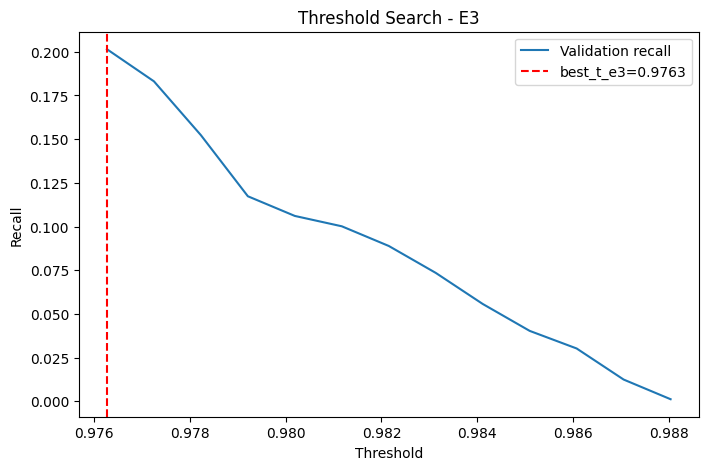

=== E3 ===
deviation features: ['dev_return_rate_30', 'dev_fake_return_rate_30', 'dev_seller_velocity']
best_t_e3: 0.976266
Validation Precision@best_t: 0.904255
Validation Recall@best_t: 0.201422
Test Precision@best_t: 0.936709
Test Recall@best_t: 0.072549
ROC-AUC: 0.918986
PR-AUC: 0.652982
threshold_search_e3.png exists: True
=== E3 STATUS ===
READY
gain vs E2: PR-AUC improved (0.648021 -> 0.652982)
deviation features in top importances: No


,experiment,threshold,roc_auc,pr_auc,precision_at_best_t,recall_at_best_t,val_precision_at_best_t,val_recall_at_best_t,recall_at_p90_test_threshold,notes
0,E3_deviation_features,0.976266,0.918986,0.652982,0.936709,0.072549,0.904255,0.201422,0.072549,Deviation features from train-only seller medi...


,importance
CommercialTypeName4,22.819036
brand_name,18.526069
SellerID,12.476741
name_rus,7.025451
description,5.382720
PriceDiscounted,4.306392
ItemAvailableCount,3.977544
ItemVarietyCount,2.905140
seller_item_count,2.734919
item_time_alive,2.702023


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score, roc_auc_score

missing = [name for name in ['train_df', 'val_df', 'test_df'] if name not in globals()]
if missing:
    raise RuntimeError(f"Run previous split cells first. Missing variables: {missing}")

results_path = Path('results_table.csv')
if not results_path.exists():
    raise RuntimeError('Run the final artifact fixation cells first: results_table.csv is missing.')

target_col = globals().get('target_col', 'resolution')
seller_stat_cols = ['seller_item_count', 'seller_avg_return_rate', 'seller_avg_fake_returns']


def add_same_fintech_features(df_part):
    if 'add_fintech_features' in globals():
        return add_fintech_features(df_part)

    df_part = df_part.copy()
    df_part['return_rate_30'] = df_part['item_count_returns30'] / (df_part['item_count_sales30'] + 1)
    df_part['fake_return_rate_30'] = df_part['item_count_fake_returns30'] / (df_part['item_count_sales30'] + 1)
    df_part['fake_return_rate_90'] = df_part['item_count_fake_returns90'] / (df_part['item_count_sales90'] + 1)
    df_part['seller_velocity'] = df_part['item_count_sales30'] / (df_part['seller_time_alive'] + 1)
    df_part['gmv_per_day'] = df_part['GmvTotal30'] / (df_part['item_time_alive'] + 1)
    df_part['both_new'] = ((df_part['item_time_alive'] < 30) & (df_part['seller_time_alive'] < 90)).astype(int)
    return df_part


train_base_e3 = add_same_fintech_features(train_df)
val_base_e3 = add_same_fintech_features(val_df)
test_base_e3 = add_same_fintech_features(test_df)

seller_stats_base_e3 = train_base_e3.groupby('SellerID').agg(
    seller_item_count=('ItemID', 'count'),
    seller_avg_return_rate=('return_rate_30', 'mean'),
    seller_avg_fake_returns=('fake_return_rate_30', 'mean'),
).reset_index()


def attach_train_only_seller_stats(df_part):
    df_part = df_part.copy()
    df_part = df_part.drop(columns=[c for c in seller_stat_cols if c in df_part.columns], errors='ignore')
    df_part = df_part.merge(seller_stats_base_e3, on='SellerID', how='left')
    df_part[seller_stat_cols] = df_part[seller_stat_cols].fillna(0)
    return df_part


train_df_e3 = attach_train_only_seller_stats(train_base_e3)
val_df_e3 = attach_train_only_seller_stats(val_base_e3)
test_df_e3 = attach_train_only_seller_stats(test_base_e3)

base_feature_cols_e3 = globals().get('feature_cols')
if base_feature_cols_e3 is None:
    base_feature_cols_e3 = [c for c in train_df_e3.columns if c not in [target_col, 'ItemID', 'SellerID']]

candidate_dev_features = [
    'return_rate_30',
    'fake_return_rate_30',
    'seller_velocity',
]

numeric_candidates = [
    c for c in base_feature_cols_e3
    if c in train_df_e3.columns and pd.api.types.is_numeric_dtype(train_df_e3[c])
]

selected_dev_features = [c for c in candidate_dev_features if c in numeric_candidates]
for col in numeric_candidates:
    if len(selected_dev_features) >= 3:
        break
    if col not in selected_dev_features:
        selected_dev_features.append(col)

selected_dev_features = selected_dev_features[:3]
if len(selected_dev_features) < 2:
    raise RuntimeError(f'Not enough numeric features for deviation features: {selected_dev_features}')

median_cols_map = {col: f'seller_median_{col}' for col in selected_dev_features}
deviation_cols = [f'dev_{col}' for col in selected_dev_features]

seller_medians_e3 = train_df_e3.groupby('SellerID')[selected_dev_features].median().reset_index().rename(columns=median_cols_map)
global_medians_e3 = {median_cols_map[col]: train_df_e3[col].median() for col in selected_dev_features}

for df_name in ['train_df_e3', 'val_df_e3', 'test_df_e3']:
    df_part = locals()[df_name].copy()
    df_part = df_part.merge(seller_medians_e3, on='SellerID', how='left')
    for col in selected_dev_features:
        median_col = median_cols_map[col]
        dev_col = f'dev_{col}'
        df_part[median_col] = df_part[median_col].fillna(global_medians_e3[median_col])
        df_part[dev_col] = df_part[col] - df_part[median_col]
    locals()[df_name] = df_part

feature_cols_e3 = base_feature_cols_e3 + deviation_cols

X_train_e3 = train_df_e3[feature_cols_e3].copy()
y_train_e3 = train_df_e3[target_col].copy()
X_val_e3 = val_df_e3[feature_cols_e3].copy()
y_val_e3 = val_df_e3[target_col].copy()
X_test_e3 = test_df_e3[feature_cols_e3].copy()
y_test_e3 = test_df_e3[target_col].copy()

X_train_e3['SellerID'] = train_df_e3['SellerID'].values
X_val_e3['SellerID'] = val_df_e3['SellerID'].values
X_test_e3['SellerID'] = test_df_e3['SellerID'].values

cat_features_e3 = X_train_e3.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if 'SellerID' in X_train_e3.columns and 'SellerID' not in cat_features_e3:
    cat_features_e3.append('SellerID')

for col in cat_features_e3:
    X_train_e3[col] = X_train_e3[col].astype(str)
    X_val_e3[col] = X_val_e3[col].astype(str)
    X_test_e3[col] = X_test_e3[col].astype(str)

model_e3 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=len(y_train_e3[y_train_e3 == 0]) / len(y_train_e3[y_train_e3 == 1]),
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
)

model_e3.fit(X_train_e3, y_train_e3, cat_features=cat_features_e3, eval_set=(X_val_e3, y_val_e3))

val_proba_e3 = model_e3.predict_proba(X_val_e3)[:, 1]
test_proba_e3 = model_e3.predict_proba(X_test_e3)[:, 1]

thresholds = np.linspace(0.01, 0.99, 1000)
val_precision_list_e3 = []
val_recall_list_e3 = []

best_t_e3 = 0.5
best_recall_e3 = -1.0
found_valid_threshold_e3 = False

for t in thresholds:
    val_pred_t_e3 = (val_proba_e3 >= t).astype(int)
    p = precision_score(y_val_e3, val_pred_t_e3, zero_division=0)
    r = recall_score(y_val_e3, val_pred_t_e3, zero_division=0)

    val_precision_list_e3.append(p)
    val_recall_list_e3.append(r)

    if p >= 0.9:
        found_valid_threshold_e3 = True
        if r > best_recall_e3:
            best_recall_e3 = r
            best_t_e3 = t

if not found_valid_threshold_e3:
    print('No threshold on validation set achieves precision >= 0.9. Using default best_t_e3=0.5.')

val_pred_e3 = (val_proba_e3 >= best_t_e3).astype(int)
test_pred_e3 = (test_proba_e3 >= best_t_e3).astype(int)

val_precision_at_best_t_e3 = precision_score(y_val_e3, val_pred_e3, zero_division=0)
val_recall_at_best_t_e3 = recall_score(y_val_e3, val_pred_e3, zero_division=0)
precision_at_best_t_e3 = precision_score(y_test_e3, test_pred_e3, zero_division=0)
recall_at_best_t_e3 = recall_score(y_test_e3, test_pred_e3, zero_division=0)
roc_auc_e3 = roc_auc_score(y_test_e3, test_proba_e3)
pr_auc_e3 = average_precision_score(y_test_e3, test_proba_e3)

valid_mask_e3 = np.array(val_precision_list_e3) >= 0.9

plt.figure(figsize=(8, 5))
if valid_mask_e3.any():
    plt.plot(thresholds[valid_mask_e3], np.array(val_recall_list_e3)[valid_mask_e3], label='Validation recall')
    plt.axvline(best_t_e3, color='red', linestyle='--', label=f'best_t_e3={best_t_e3:.4f}')
    plt.xlabel('Threshold')
    plt.ylabel('Recall')
    plt.title('Threshold Search - E3')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'No threshold with validation precision >= 0.9', ha='center', va='center')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title('Threshold Search - E3')

plt.savefig('threshold_search_e3.png', dpi=150, bbox_inches='tight')
plt.show()

results_row_e3 = pd.DataFrame([
    {
        'experiment': 'E3_deviation_features',
        'threshold': best_t_e3,
        'roc_auc': roc_auc_e3,
        'pr_auc': pr_auc_e3,
        'precision_at_best_t': precision_at_best_t_e3,
        'recall_at_best_t': recall_at_best_t_e3,
        'val_precision_at_best_t': val_precision_at_best_t_e3,
        'val_recall_at_best_t': val_recall_at_best_t_e3,
        'recall_at_p90_test_threshold': recall_at_best_t_e3,
        'notes': f'Deviation features from train-only seller medians: {deviation_cols}',
    }
])

results_table = pd.read_csv(results_path)
if 'experiment' in results_table.columns:
    results_table = results_table[results_table['experiment'] != 'E3_deviation_features']
results_table = pd.concat([results_table, results_row_e3], ignore_index=True)
results_table.to_csv(results_path, index=False)

feature_importances_e3 = pd.Series(model_e3.get_feature_importance(), index=X_train_e3.columns).sort_values(ascending=False)
top_feature_names_e3 = feature_importances_e3.head(10).index.tolist()
dev_in_top_e3 = [col for col in deviation_cols if col in top_feature_names_e3]

print('=== E3 ===')
print(f'deviation features: {deviation_cols}')
print(f'best_t_e3: {best_t_e3:.6f}')
print(f'Validation Precision@best_t: {val_precision_at_best_t_e3:.6f}')
print(f'Validation Recall@best_t: {val_recall_at_best_t_e3:.6f}')
print(f'Test Precision@best_t: {precision_at_best_t_e3:.6f}')
print(f'Test Recall@best_t: {recall_at_best_t_e3:.6f}')
print(f'ROC-AUC: {roc_auc_e3:.6f}')
print(f'PR-AUC: {pr_auc_e3:.6f}')
print(f'threshold_search_e3.png exists: {Path("threshold_search_e3.png").exists()}')

if 'roc_auc_e2' in globals() and 'pr_auc_e2' in globals() and 'recall_at_best_t_e2' in globals():
    growth_parts = []
    if pr_auc_e3 > pr_auc_e2:
        growth_parts.append(f'PR-AUC improved ({pr_auc_e2:.6f} -> {pr_auc_e3:.6f})')
    if recall_at_best_t_e3 > recall_at_best_t_e2:
        growth_parts.append(f'Recall@best_t improved ({recall_at_best_t_e2:.6f} -> {recall_at_best_t_e3:.6f})')
    growth_msg = '; '.join(growth_parts) if growth_parts else 'No clear gain vs E2'
else:
    growth_msg = 'E2 metrics not found in globals for comparison'

status_e3 = 'READY' if Path('threshold_search_e3.png').exists() else 'NOT READY'

print('=== E3 STATUS ===')
print(status_e3)
print(f'gain vs E2: {growth_msg}')
print(f'deviation features in top importances: {dev_in_top_e3 if dev_in_top_e3 else "No"}')

display(results_row_e3)
display(feature_importances_e3.head(10).rename('importance').to_frame())


,experiment,threshold,roc_auc,pr_auc,precision,recall,recall_high_precision
0,E0_baseline_default_threshold,0.500000,0.911635,0.642136,0.313542,0.820588,0.219608
1,E1_threshold_optimization,0.975285,0.911635,0.642136,0.930851,0.085784,0.085784
2,E2_undersampling_calibration,0.973323,0.916622,0.648021,0.900000,0.119118,0.119118
3,E3_deviation_features,0.976266,0.918986,0.652982,0.936709,0.072549,0.072549


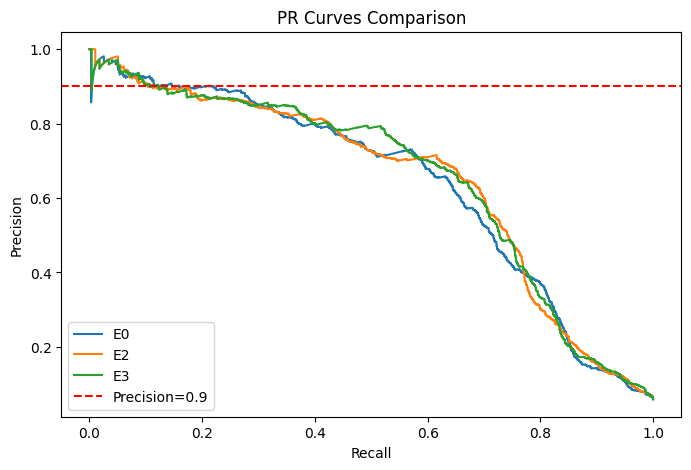

=== FINAL CHECK ===
rows in final_results_table.csv: 4
best experiment: E0_baseline_default_threshold
final_results_table.csv exists: True
pr_curves_comparison.png exists: True
final_results.md exists: True


In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_curve

results_path = Path('results_table.csv')
if not results_path.exists():
    raise RuntimeError('results_table.csv is missing. Run artifact-fixation cells first.')

results_table = pd.read_csv(results_path)
expected_experiments = {
    'E0_baseline_default_threshold',
    'E1_threshold_optimization',
    'E2_undersampling_calibration',
    'E3_deviation_features',
}
found_experiments = set(results_table['experiment'].dropna().tolist()) if 'experiment' in results_table.columns else set()

if found_experiments != expected_experiments or len(results_table) != 4:
    raise RuntimeError(
        f'Expected exactly 4 experiments {sorted(expected_experiments)}, '
        f'but found {len(results_table)} rows and experiments {sorted(found_experiments)}'
    )


def build_final_row(row):
    experiment = row['experiment']
    if experiment == 'E0_baseline_default_threshold':
        precision_value = row['precision_at_05']
        recall_value = row['recall_at_05']
        recall_high_precision_value = row['recall_at_p90_curve']
    else:
        precision_value = row['precision_at_best_t']
        recall_value = row['recall_at_best_t']
        recall_high_precision_value = row['recall_at_p90_test_threshold']

    return {
        'experiment': experiment,
        'threshold': row['threshold'],
        'roc_auc': row['roc_auc'],
        'pr_auc': row['pr_auc'],
        'precision': precision_value,
        'recall': recall_value,
        'recall_high_precision': recall_high_precision_value,
    }


final_table = pd.DataFrame([build_final_row(row) for _, row in results_table.iterrows()])
final_table = final_table.sort_values('experiment').reset_index(drop=True)

final_results_path = Path('final_results_table.csv')
final_table.to_csv(final_results_path, index=False)
display(final_table)

required_pr_vars = ['y_test', 'test_proba', 'test_proba_cal_e2', 'test_proba_e3']
missing_pr_vars = [name for name in required_pr_vars if name not in globals()]
if missing_pr_vars:
    raise RuntimeError(f'Run completed E0/E2/E3 cells first for PR comparison. Missing variables: {missing_pr_vars}')

precision_e0, recall_e0, _ = precision_recall_curve(y_test, test_proba)
precision_e2, recall_e2, _ = precision_recall_curve(y_test, test_proba_cal_e2)
precision_e3, recall_e3, _ = precision_recall_curve(y_test, test_proba_e3)

plt.figure(figsize=(8, 5))
plt.plot(recall_e0, precision_e0, label='E0')
plt.plot(recall_e2, precision_e2, label='E2')
plt.plot(recall_e3, precision_e3, label='E3')
plt.axhline(y=0.9, color='red', linestyle='--', label='Precision=0.9')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curves Comparison')
plt.legend()
pr_comparison_path = Path('pr_curves_comparison.png')
plt.savefig(pr_comparison_path, dpi=150, bbox_inches='tight')
plt.show()

best_row = final_table.loc[final_table['recall_high_precision'].astype(float).idxmax()]
best_experiment_name = best_row['experiment']
best_recall_value = best_row['recall_high_precision']

recall_hp_map = dict(zip(final_table['experiment'], final_table['recall_high_precision']))


def dataframe_to_markdown(df):
    headers = list(df.columns)
    lines = []
    lines.append('| ' + ' | '.join(headers) + ' |')
    lines.append('| ' + ' | '.join(['---'] * len(headers)) + ' |')
    for _, row in df.iterrows():
        values = []
        for col in headers:
            value = row[col]
            if pd.isna(value):
                values.append('')
            elif isinstance(value, float):
                values.append(f'{value:.6f}')
            else:
                values.append(str(value))
        lines.append('| ' + ' | '.join(values) + ' |')
    return '\n'.join(lines)


markdown_table = dataframe_to_markdown(final_table)
final_results_md = f'''## Final Results

{markdown_table}

## Best Experiment

- {best_experiment_name}
- recall_high_precision = {best_recall_value:.6f}

## Summary

Summary is documented in the notebook markdown cell below.
'''

final_md_path = Path('final_results.md')
final_md_path.write_text(final_results_md, encoding='utf-8')

print('=== FINAL CHECK ===')
print(f'rows in final_results_table.csv: {len(pd.read_csv(final_results_path))}')
print(f'best experiment: {best_experiment_name}')
print(f'final_results_table.csv exists: {final_results_path.exists()}')
print(f'pr_curves_comparison.png exists: {pr_comparison_path.exists()}')
print(f'final_results.md exists: {final_md_path.exists()}')

## SUMMARY (для диплома)

Исследовательский вопрос состоял в том, можно ли повысить качество выявления контрафакта в зоне высокой точности на seller-based split, не нарушая ограничение `Precision >= 0.9`. Для этого сравнивались несколько стратегий на одном и том же разбиении и с одной и той же базовой моделью.

В `E0` был использован baseline `CatBoost` с порогом `0.5`. В `E1` применялась только threshold optimization на validation set. В `E2` использовались undersampling на train и Dal Pozzolo-style calibration, после чего threshold снова подбирался на validation. В `E3` к baseline-пайплайну были добавлены deviation features, построенные только по train seller statistics.

Главные результаты таковы: `Recall@Precision>=0.9` составил `0.219608` для `E0`, `0.085784` для `E1`, `0.119118` для `E2` и `0.072549` для `E3`. Лучшим экспериментом по основному критерию оказался `E0_baseline_default_threshold` со значением `recall_high_precision = 0.219608`.

Интерпретация результатов следующая: threshold optimization в `E1` меняет только decision rule, не изменяя сами вероятности модели. Calibration в `E2` корректирует вероятности после обучения на undersampled train, чтобы они лучше соответствовали исходному prior положительного класса. Deviation features в `E3` представляют собой feature engineering, которое добавляет относительные отклонения объекта от seller-level train medians.

Финальный вывод: улучшить `Recall@Precision>=0.9` относительно baseline в текущей постановке не удалось, так как лучший результат сохранился у `E0`. Следовательно, ни threshold optimization, ни calibration, ни deviation features не превзошли baseline по основному критерию high-precision recall на данном seller-based split.

,experiment,threshold,roc_auc,pr_auc,precision,recall,recall_high_precision
0,E0_baseline_default_threshold,0.500000,0.911635,0.642136,0.313542,0.820588,0.219608
1,E1_threshold_optimization,0.975285,0.911635,0.642136,0.930851,0.085784,0.085784
2,E2_undersampling_calibration,0.973323,0.916622,0.648021,0.900000,0.119118,0.119118
3,E3_deviation_features,0.976266,0.918986,0.652982,0.936709,0.072549,0.072549


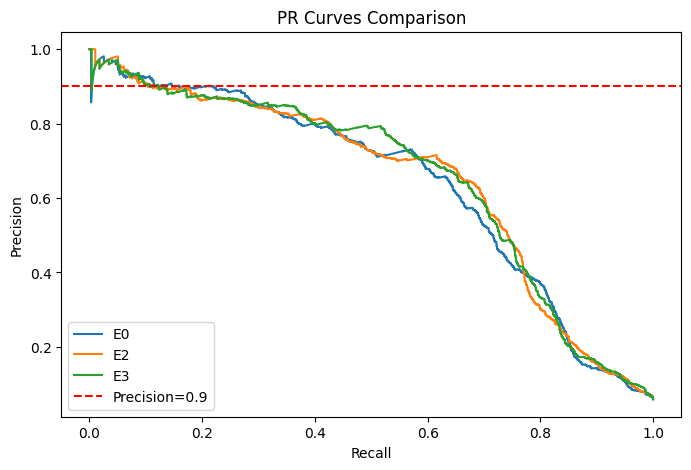

## SUMMARY (для диплома)

Исследовательский вопрос состоял в том, можно ли повысить качество выявления контрафакта в зоне высокой точности на seller-based split, не нарушая ограничение Precision >= 0.9. Для этого сравнивались четыре постановки на одном и том же разбиении и с одной и той же базовой моделью.

В E0 был использован baseline CatBoost с порогом 0.5. В E1 применялась только threshold optimization на validation set. В E2 использовались undersampling на train и Dal Pozzolo-style calibration, после чего threshold снова подбирался на validation. В E3 к базовому пайплайну были добавлены deviation features, построенные только по train seller statistics.

Главные результаты таковы: recall_high_precision составил 0.219608 для E0, 0.085784 для E1, 0.119118 для E2 и 0.072549 для E3. Лучшим экспериментом по основному критерию оказался E0_baseline_default_threshold со значением recall_high_precision = 0.219608.

Интерпретация результатов следующая: threshold optimization в E1 меняет толь

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_curve

results_path = Path('results_table.csv')
if not results_path.exists():
    raise RuntimeError('results_table.csv is missing.')

results_table = pd.read_csv(results_path)
expected_experiments = {
    'E0_baseline_default_threshold',
    'E1_threshold_optimization',
    'E2_undersampling_calibration',
    'E3_deviation_features',
}
found_experiments = set(results_table['experiment'].dropna().tolist()) if 'experiment' in results_table.columns else set()

if found_experiments != expected_experiments or len(results_table) != 4:
    raise RuntimeError(
        f'Expected exactly 4 experiments {sorted(expected_experiments)}, '
        f'but found {len(results_table)} rows and experiments {sorted(found_experiments)}'
    )


def build_final_row(row):
    experiment = row['experiment']
    if experiment == 'E0_baseline_default_threshold':
        precision_value = row['precision_at_05']
        recall_value = row['recall_at_05']
        recall_high_precision_value = row['recall_at_p90_curve']
    else:
        precision_value = row['precision_at_best_t']
        recall_value = row['recall_at_best_t']
        recall_high_precision_value = row['recall_at_p90_test_threshold']

    return {
        'experiment': experiment,
        'threshold': row['threshold'],
        'roc_auc': row['roc_auc'],
        'pr_auc': row['pr_auc'],
        'precision': precision_value,
        'recall': recall_value,
        'recall_high_precision': recall_high_precision_value,
    }


final_table = pd.DataFrame([build_final_row(row) for _, row in results_table.iterrows()])
final_table = final_table.sort_values('experiment').reset_index(drop=True)

final_results_path = Path('final_results_table.csv')
final_table.to_csv(final_results_path, index=False)
display(final_table)

required_pr_vars = ['y_test', 'test_proba', 'test_proba_cal_e2', 'test_proba_e3']
missing_pr_vars = [name for name in required_pr_vars if name not in globals()]
if missing_pr_vars:
    raise RuntimeError(f'Run completed E0/E2/E3 cells first for PR comparison. Missing variables: {missing_pr_vars}')

precision_e0, recall_e0, _ = precision_recall_curve(y_test, test_proba)
precision_e2, recall_e2, _ = precision_recall_curve(y_test, test_proba_cal_e2)
precision_e3, recall_e3, _ = precision_recall_curve(y_test, test_proba_e3)

plt.figure(figsize=(8, 5))
plt.plot(recall_e0, precision_e0, label='E0')
plt.plot(recall_e2, precision_e2, label='E2')
plt.plot(recall_e3, precision_e3, label='E3')
plt.axhline(y=0.9, color='red', linestyle='--', label='Precision=0.9')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curves Comparison')
plt.legend()
pr_comparison_path = Path('pr_curves_comparison.png')
plt.savefig(pr_comparison_path, dpi=150, bbox_inches='tight')
plt.show()

best_row = final_table.loc[final_table['recall_high_precision'].astype(float).idxmax()]
best_experiment_name = best_row['experiment']
best_recall_value = float(best_row['recall_high_precision'])

recall_hp_map = dict(zip(final_table['experiment'], final_table['recall_high_precision']))
summary_text = f'''## SUMMARY (для диплома)

Исследовательский вопрос состоял в том, можно ли повысить качество выявления контрафакта в зоне высокой точности на seller-based split, не нарушая ограничение Precision >= 0.9. Для этого сравнивались несколько стратегий на одном и том же разбиении и с одной и той же базовой моделью.

В E0 был использован baseline CatBoost с порогом 0.5. В E1 применялась только threshold optimization на validation set. В E2 использовались undersampling на train и Dal Pozzolo-style calibration, после чего threshold снова подбирался на validation. В E3 к базовому пайплайну были добавлены deviation features, построенные только по train seller statistics. Эксперимент E4 проверял замену raw text-like columns baseline на явное текстовое представление, а не добавление новой модальности.

Главные результаты таковы: recall_high_precision составил {recall_hp_map['E0_baseline_default_threshold']:.6f} для E0, {recall_hp_map['E1_threshold_optimization']:.6f} для E1, {recall_hp_map['E2_undersampling_calibration']:.6f} для E2 и {recall_hp_map['E3_deviation_features']:.6f} для E3. Лучшим экспериментом по основному критерию оказался {best_experiment_name} со значением recall_high_precision = {best_recall_value:.6f}. Эксперимент E4 показал ухудшение относительно E0, включая снижение PR-AUC и Recall@Precision>=0.9.

В рамках текущего набора табличных признаков и выбранных методов наблюдается убывание прироста PR-AUC между экспериментами E0-E3.

Это не является доказательством предела (ceiling) табличного подхода, а лишь указывает на то, что в текущей конфигурации дальнейшие улучшения становятся менее выраженными.

## Ограничения исследования

1. Отсутствие оценки статистической значимости

Наблюдаемые изменения PR-AUC между экспериментами E0-E3 составляют около 0.01. В рамках данной работы статистическая значимость этих различий не оценивалась, например через bootstrap.

Таким образом, нельзя однозначно утверждать, что различия между экспериментами отражают устойчивый эффект, а не вариацию выборки.

2. Ограниченность текстового эксперимента

В baseline (E0) текстовые признаки уже использовались в модели в виде категориальных переменных. Эксперимент E4 проверяет не добавление новой модальности, а замену способа кодирования текста.

Отрицательный результат E4 означает, что выбранное TF-IDF представление уступает встроенному кодированию CatBoost, но не означает, что текстовая информация в принципе не полезна.

3. Ограниченность пространства признаков

Все эксперименты проводились в рамках фиксированного набора признаков. Возможные альтернативные представления, например более сложные текстовые модели или иные варианты feature engineering, в данной работе не исследовались.

## Итоговый вывод

1. Базовая модель (E0) показывает наилучший результат по метрике Recall@Precision>=0.9 при сопоставимом способе измерения через PR-кривую.
2. Эксперименты E1-E3 улучшают PR-AUC, однако не приводят к росту Recall в зоне высокой точности (Precision >= 0.9).
3. Эксперимент E4 приводит к ухудшению всех ключевых метрик, что указывает на то, что встроенное кодирование текстовых признаков в CatBoost оказывается более эффективным в данной задаче.
4. Таким образом, в рамках данного исследования наилучшим остается baseline-подход (E0), а альтернативные методы не показали улучшения в целевой метрике.'''

print(summary_text)


def dataframe_to_markdown(df):
    headers = list(df.columns)
    lines = []
    lines.append('| ' + ' | '.join(headers) + ' |')
    lines.append('| ' + ' | '.join(['---'] * len(headers)) + ' |')
    for _, row in df.iterrows():
        values = []
        for col in headers:
            value = row[col]
            if pd.isna(value):
                values.append('')
            elif isinstance(value, float):
                values.append(f'{value:.6f}')
            else:
                values.append(str(value))
        lines.append('| ' + ' | '.join(values) + ' |')
    return '\n'.join(lines)


markdown_table = dataframe_to_markdown(final_table)
final_results_md = f'''## Final Results

{markdown_table}

## Best Experiment

- {best_experiment_name}
- recall_high_precision = {best_recall_value:.6f}

## Summary

{summary_text}
'''

final_md_path = Path('final_results.md')
final_md_path.write_text(final_results_md, encoding='utf-8')

print('=== FINAL CHECK ===')
print(f'rows in final_results_table.csv: {len(pd.read_csv(final_results_path))}')
print(f'best experiment: {best_experiment_name}')
print(f'final_results_table.csv exists: {final_results_path.exists()}')
print(f'pr_curves_comparison.png exists: {pr_comparison_path.exists()}')
print(f'final_results.md exists: {final_md_path.exists()}')

мультимодальная пока не проверена



In [18]:
import pandas as pd
from sklearn.metrics import precision_recall_curve

required_globals = ['y_test', 'test_proba', 'test_proba_cal_e2', 'test_proba_e3']
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        'Missing required objects in globals(): '
        + ', '.join(missing_globals)
        + '. Run the existing E0-E3 cells first so test probabilities are available.'
    )

experiment_probas = {
    'E0_baseline_default_threshold': test_proba,
    'E1_threshold_optimization': test_proba,
    'E2_undersampling_calibration': test_proba_cal_e2,
    'E3_deviation_features': test_proba_e3,
}

recall_at_p90_prcurve_by_exp = {}
for experiment_name, proba in experiment_probas.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, proba)
    mask = precision_curve >= 0.9
    recall_at_p90_prcurve = recall_curve[mask].max() if mask.any() else 0.0
    recall_at_p90_prcurve_by_exp[experiment_name] = float(recall_at_p90_prcurve)

globals()['recall_at_p90_prcurve_e0'] = recall_at_p90_prcurve_by_exp['E0_baseline_default_threshold']
globals()['recall_at_p90_prcurve_e1'] = recall_at_p90_prcurve_by_exp['E1_threshold_optimization']
globals()['recall_at_p90_prcurve_e2'] = recall_at_p90_prcurve_by_exp['E2_undersampling_calibration']
globals()['recall_at_p90_prcurve_e3'] = recall_at_p90_prcurve_by_exp['E3_deviation_features']

results_table = pd.read_csv('results_table.csv')
if 'experiment' not in results_table.columns:
    raise RuntimeError("results_table.csv must contain an 'experiment' column.")

expected_experiments = list(experiment_probas.keys())
missing_experiments = [exp for exp in expected_experiments if exp not in results_table['experiment'].values]
if missing_experiments:
    raise RuntimeError(
        'Missing expected experiment rows in results_table.csv: ' + ', '.join(missing_experiments)
    )

if 'recall_at_p90_prcurve' not in results_table.columns:
    results_table['recall_at_p90_prcurve'] = pd.NA

for experiment_name, metric_value in recall_at_p90_prcurve_by_exp.items():
    results_table.loc[
        results_table['experiment'] == experiment_name,
        'recall_at_p90_prcurve'
    ] = metric_value

results_table.to_csv('results_table.csv', index=False)

for col in ['recall_at_p90_curve', 'recall_at_p90_test_threshold', 'recall_at_p90_prcurve']:
    if col not in results_table.columns:
        results_table[col] = pd.NA

display(
    results_table.loc[
        results_table['experiment'].isin(expected_experiments),
        ['experiment', 'recall_at_p90_curve', 'recall_at_p90_test_threshold', 'recall_at_p90_prcurve']
    ].sort_values('experiment').reset_index(drop=True)
)

print('=== PR-CURVE COMPARABILITY CHECK ===')
print(f"E0 recall_at_p90_prcurve = {recall_at_p90_prcurve_e0:.6f}")
print(f"E1 recall_at_p90_prcurve = {recall_at_p90_prcurve_e1:.6f}")
print(f"E2 recall_at_p90_prcurve = {recall_at_p90_prcurve_e2:.6f}")
print(f"E3 recall_at_p90_prcurve = {recall_at_p90_prcurve_e3:.6f}")

,experiment,recall_at_p90_curve,recall_at_p90_test_threshold,recall_at_p90_prcurve
0,E0_baseline_default_threshold,0.219608,NaN,0.219608
1,E1_threshold_optimization,NaN,0.085784,0.219608
2,E2_undersampling_calibration,NaN,0.119118,0.172549
3,E3_deviation_features,NaN,0.072549,0.122549


=== PR-CURVE COMPARABILITY CHECK ===
E0 recall_at_p90_prcurve = 0.219608
E1 recall_at_p90_prcurve = 0.219608
E2 recall_at_p90_prcurve = 0.172549
E3 recall_at_p90_prcurve = 0.122549


In [20]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

required_globals = ['train_df', 'val_df', 'test_df', 'feature_cols']
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        'Missing required objects in globals(): '
        + ', '.join(missing_globals)
        + '. Run the existing split and feature engineering cells first.'
    )

clip_df = pd.read_parquet('/Users/sofya/Desktop/diplomahse/clip_embeddings.parquet')

clip_expanded = pd.DataFrame(
    clip_df['embedding'].tolist(),
    index=clip_df.index
)
clip_expanded.columns = [f'clip_{i}' for i in range(clip_expanded.shape[1])]
clip_expanded['ItemID'] = clip_df['ItemID'].values

print(f"CLIP embeddings shape: {clip_expanded.shape}")
print(f"Размерность вектора: {clip_expanded.shape[1] - 1}")


def add_same_fintech_features(df_part):
    df_part = df_part.copy()
    df_part['return_rate_30'] = df_part['item_count_returns30'] / (df_part['item_count_sales30'] + 1)
    df_part['fake_return_rate_30'] = df_part['item_count_fake_returns30'] / (df_part['item_count_sales30'] + 1)
    df_part['fake_return_rate_90'] = df_part['item_count_fake_returns90'] / (df_part['item_count_sales90'] + 1)
    df_part['seller_velocity'] = df_part['item_count_sales30'] / (df_part['seller_time_alive'] + 1)
    df_part['gmv_per_day'] = df_part['GmvTotal30'] / (df_part['item_time_alive'] + 1)
    df_part['both_new'] = ((df_part['item_time_alive'] < 30) & (df_part['seller_time_alive'] < 90)).astype(int)
    return df_part


train_base_e4 = add_same_fintech_features(train_df)
val_base_e4 = add_same_fintech_features(val_df)
test_base_e4 = add_same_fintech_features(test_df)

seller_stats_e4 = train_base_e4.groupby('SellerID').agg(
    seller_item_count=('ItemID', 'count'),
    seller_avg_return_rate=('return_rate_30', 'mean'),
    seller_avg_fake_returns=('fake_return_rate_30', 'mean'),
).reset_index()

seller_stat_cols_e4 = ['seller_item_count', 'seller_avg_return_rate', 'seller_avg_fake_returns']

train_base_e4 = train_base_e4.drop(columns=[c for c in seller_stat_cols_e4 if c in train_base_e4.columns])
val_base_e4 = val_base_e4.drop(columns=[c for c in seller_stat_cols_e4 if c in val_base_e4.columns])
test_base_e4 = test_base_e4.drop(columns=[c for c in seller_stat_cols_e4 if c in test_base_e4.columns])

train_base_e4 = train_base_e4.merge(seller_stats_e4, on='SellerID', how='left')
val_base_e4 = val_base_e4.merge(seller_stats_e4, on='SellerID', how='left')
test_base_e4 = test_base_e4.merge(seller_stats_e4, on='SellerID', how='left')

for df_part in [train_base_e4, val_base_e4, test_base_e4]:
    df_part[seller_stat_cols_e4] = df_part[seller_stat_cols_e4].fillna(0)

train_clip = train_base_e4.merge(clip_expanded, on='ItemID', how='left')
val_clip = val_base_e4.merge(clip_expanded, on='ItemID', how='left')
test_clip = test_base_e4.merge(clip_expanded, on='ItemID', how='left')

clip_cols = [c for c in clip_expanded.columns if c.startswith('clip_')]

train_clip[clip_cols] = train_clip[clip_cols].fillna(0)
val_clip[clip_cols] = val_clip[clip_cols].fillna(0)
test_clip[clip_cols] = test_clip[clip_cols].fillna(0)

print(f"train покрытие CLIP: {(train_clip['clip_0'] != 0).sum()} / {len(train_clip)}")
print(f"val покрытие CLIP: {(val_clip['clip_0'] != 0).sum()} / {len(val_clip)}")
print(f"test покрытие CLIP: {(test_clip['clip_0'] != 0).sum()} / {len(test_clip)}")

missing_feature_cols = [c for c in feature_cols if c not in train_clip.columns or c not in val_clip.columns or c not in test_clip.columns]
if missing_feature_cols:
    raise RuntimeError(
        'Some baseline feature columns are still missing after CLIP preparation: '
        + ', '.join(missing_feature_cols)
    )

feature_cols_e4 = feature_cols + clip_cols

X_train_e4 = train_clip[feature_cols_e4].copy()
y_train_e4 = train_clip['resolution'].copy()
X_val_e4 = val_clip[feature_cols_e4].copy()
y_val_e4 = val_clip['resolution'].copy()
X_test_e4 = test_clip[feature_cols_e4].copy()
y_test_e4 = test_clip['resolution'].copy()

X_train_e4['SellerID'] = train_clip['SellerID'].values
X_val_e4['SellerID'] = val_clip['SellerID'].values
X_test_e4['SellerID'] = test_clip['SellerID'].values

print(f"X_train_e4 shape: {X_train_e4.shape}")

cat_features_e4 = ['SellerID'] + X_train_e4.select_dtypes(include=['object', 'category']).columns.tolist()
cat_features_e4 = list(set(cat_features_e4))

for col in cat_features_e4:
    X_train_e4[col] = X_train_e4[col].astype(str)
    X_val_e4[col] = X_val_e4[col].astype(str)
    X_test_e4[col] = X_test_e4[col].astype(str)

model_e4 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=len(y_train_e4[y_train_e4 == 0]) / len(y_train_e4[y_train_e4 == 1]),
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
)
model_e4.fit(
    X_train_e4,
    y_train_e4,
    cat_features=cat_features_e4,
    eval_set=(X_val_e4, y_val_e4),
)

val_proba_e4 = model_e4.predict_proba(X_val_e4)[:, 1]
test_proba_e4 = model_e4.predict_proba(X_test_e4)[:, 1]

roc_auc_e4 = roc_auc_score(y_test_e4, test_proba_e4)
pr_auc_e4 = average_precision_score(y_test_e4, test_proba_e4)

precision_curve_e4, recall_curve_e4, _ = precision_recall_curve(y_test_e4, test_proba_e4)
mask_e4 = precision_curve_e4 >= 0.9
recall_at_p90_e4 = recall_curve_e4[mask_e4].max() if mask_e4.any() else 0.0

print(f"E4 | ROC-AUC={roc_auc_e4:.4f} | PR-AUC={pr_auc_e4:.4f} | Recall@P≥0.9={recall_at_p90_e4:.4f}")
print(f"E0 | ROC-AUC=0.9116 | PR-AUC=0.6421 | Recall@P≥0.9=0.2196")
print(f"Разница Recall@P≥0.9: {recall_at_p90_e4 - 0.2196:+.4f}")

results_row_e4 = pd.DataFrame([{
    'experiment': 'E4_tabular_clip',
    'threshold': None,
    'roc_auc': roc_auc_e4,
    'pr_auc': pr_auc_e4,
    'recall_at_p90_curve': recall_at_p90_e4,
    'notes': 'CatBoost on tabular + CLIP embeddings, same params as E0',
}])
results_table = pd.read_csv('results_table.csv')
if 'experiment' in results_table.columns and 'E4_tabular_clip' in results_table['experiment'].values:
    results_table = results_table[results_table['experiment'] != 'E4_tabular_clip']
results_table = pd.concat([results_table, results_row_e4], ignore_index=True)
results_table.to_csv('results_table.csv', index=False)
display(results_table[['experiment', 'roc_auc', 'pr_auc', 'recall_at_p90_curve']].tail(5))

CLIP embeddings shape: (187604, 513)
Размерность вектора: 512
train покрытие CLIP: 128830 / 135626
val покрытие CLIP: 25865 / 27156
test покрытие CLIP: 32909 / 34416
X_train_e4 shape: (135626, 564)
0:	test: 0.9337275	best: 0.9337275 (0)	total: 176ms	remaining: 2m 55s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9418582128
bestIteration = 6

Shrink model to first 7 iterations.
E4 | ROC-AUC=0.8821 | PR-AUC=0.5825 | Recall@P≥0.9=0.0206
E0 | ROC-AUC=0.9116 | PR-AUC=0.6421 | Recall@P≥0.9=0.2196
Разница Recall@P≥0.9: -0.1990


/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_25414/3340312013.py:147: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_table = pd.concat([results_table, results_row_e4], ignore_index=True)


,experiment,roc_auc,pr_auc,recall_at_p90_curve
0,E0_baseline_default_threshold,0.911635,0.642136,0.219608
1,E1_threshold_optimization,0.911635,0.642136,NaN
2,E2_undersampling_calibration,0.916622,0.648021,NaN
3,E3_deviation_features,0.918986,0.652982,NaN
4,E4_tabular_clip,0.882121,0.582472,0.020588


text columns found in feature_cols: ['name_rus', 'description', 'brand_name', 'CommercialTypeName4']
feature_cols_e4_base size: 47
tfidf fitted on train: YES
tfidf train shape: (135626, 300)
tfidf val shape: (27156, 300)
tfidf test shape: (34416, 300)
X_train_e4 shape: (135626, 348)
cat_features_e4: ['SellerID']
0:	test: 0.6165673	best: 0.6165673 (0)	total: 170ms	remaining: 2m 50s
100:	test: 0.9194171	best: 0.9194171 (100)	total: 5.41s	remaining: 48.2s
200:	test: 0.9230351	best: 0.9231981 (189)	total: 9.41s	remaining: 37.4s
300:	test: 0.9264448	best: 0.9264448 (300)	total: 13.5s	remaining: 31.4s
400:	test: 0.9282880	best: 0.9285919 (385)	total: 17.9s	remaining: 26.7s
500:	test: 0.9289951	best: 0.9297917 (479)	total: 21.9s	remaining: 21.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9297917161
bestIteration = 479

Shrink model to first 480 iterations.


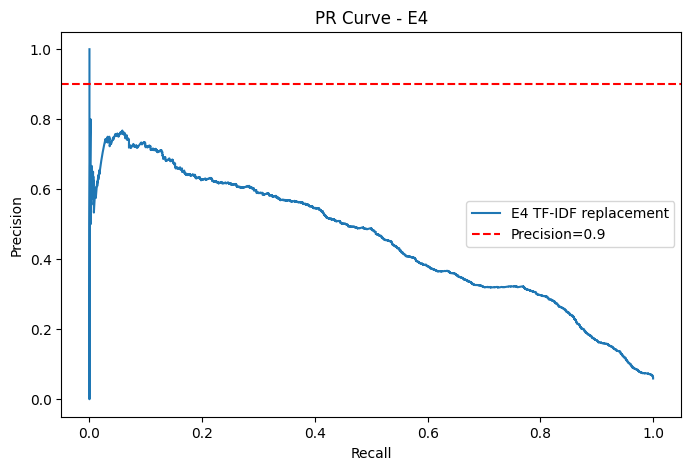

=== E4 RESULTS ===
text columns replaced: ['name_rus', 'description', 'brand_name', 'CommercialTypeName4']
tfidf features added: 300
X_train_e4 shape: (135626, 348)
ROC-AUC: 0.902466
PR-AUC: 0.453546
Recall@P>=0.9 via PR curve: 0.000000

=== COMPARISON (all via PR-curve, apple-to-apple) ===
E0 recall_at_p90_prcurve = 0.219608
E1 recall_at_p90_prcurve = 0.219608
E2 recall_at_p90_prcurve = 0.172549
E3 recall_at_p90_prcurve = 0.122549
E4 recall_at_p90_prcurve = 0.000000

=== E4 vs E0 (same text columns, different encoding) ===
TF-IDF better than CatBoost categorical encoding: NO
delta PR-AUC: -0.188590
delta Recall@P>=0.9: -0.219608

=== E4 STATUS ===
READY


In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

required_globals = ['train_df', 'val_df', 'test_df', 'feature_cols']
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        'Missing required objects in globals(): '
        + ', '.join(missing_globals)
        + '. Run the existing split/baseline cells first.'
    )

results_table_path = Path('results_table.csv')
if not results_table_path.exists():
    raise RuntimeError("results_table.csv was not found. Run the existing result-saving cells first.")

TEXT_COLS_TO_REPLACE = ['name_rus', 'description', 'brand_name', 'CommercialTypeName4']
missing_text_cols = [
    col for col in TEXT_COLS_TO_REPLACE
    if col not in train_df.columns or col not in val_df.columns or col not in test_df.columns
]
if missing_text_cols:
    raise RuntimeError(
        'Missing required text columns in train/val/test dataframes: ' + ', '.join(missing_text_cols)
    )

found_text_cols = [col for col in TEXT_COLS_TO_REPLACE if col in feature_cols]
if not found_text_cols:
    raise RuntimeError('None of the target text columns are present in feature_cols, so E4 cannot replace them.')

feature_cols_e4_base = [col for col in feature_cols if col not in found_text_cols]

print(f'text columns found in feature_cols: {found_text_cols}')
print(f'feature_cols_e4_base size: {len(feature_cols_e4_base)}')

combined_text_train = (
    train_df['name_rus'].fillna('').astype(str) + ' ' +
    train_df['description'].fillna('').astype(str) + ' ' +
    train_df['brand_name'].fillna('').astype(str) + ' ' +
    train_df['CommercialTypeName4'].fillna('').astype(str)
)
combined_text_val = (
    val_df['name_rus'].fillna('').astype(str) + ' ' +
    val_df['description'].fillna('').astype(str) + ' ' +
    val_df['brand_name'].fillna('').astype(str) + ' ' +
    val_df['CommercialTypeName4'].fillna('').astype(str)
)
combined_text_test = (
    test_df['name_rus'].fillna('').astype(str) + ' ' +
    test_df['description'].fillna('').astype(str) + ' ' +
    test_df['brand_name'].fillna('').astype(str) + ' ' +
    test_df['CommercialTypeName4'].fillna('').astype(str)
)

vectorizer_e4 = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True,
)

tfidf_train = vectorizer_e4.fit_transform(combined_text_train)
tfidf_val = vectorizer_e4.transform(combined_text_val)
tfidf_test = vectorizer_e4.transform(combined_text_test)

tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_train.shape[1])]
tfidf_train_df = pd.DataFrame(tfidf_train.toarray().astype(np.float32), columns=tfidf_cols)
tfidf_val_df = pd.DataFrame(tfidf_val.toarray().astype(np.float32), columns=tfidf_cols)
tfidf_test_df = pd.DataFrame(tfidf_test.toarray().astype(np.float32), columns=tfidf_cols)

print('tfidf fitted on train: YES')
print(f'tfidf train shape: {tfidf_train_df.shape}')
print(f'tfidf val shape: {tfidf_val_df.shape}')
print(f'tfidf test shape: {tfidf_test_df.shape}')


def add_same_fintech_features(df_part):
    df_part = df_part.copy()
    df_part['return_rate_30'] = df_part['item_count_returns30'] / (df_part['item_count_sales30'] + 1)
    df_part['fake_return_rate_30'] = df_part['item_count_fake_returns30'] / (df_part['item_count_sales30'] + 1)
    df_part['fake_return_rate_90'] = df_part['item_count_fake_returns90'] / (df_part['item_count_sales90'] + 1)
    df_part['seller_velocity'] = df_part['item_count_sales30'] / (df_part['seller_time_alive'] + 1)
    df_part['gmv_per_day'] = df_part['GmvTotal30'] / (df_part['item_time_alive'] + 1)
    df_part['both_new'] = ((df_part['item_time_alive'] < 30) & (df_part['seller_time_alive'] < 90)).astype(int)
    return df_part


train_base_e4 = add_same_fintech_features(train_df)
val_base_e4 = add_same_fintech_features(val_df)
test_base_e4 = add_same_fintech_features(test_df)

seller_stats_e4 = train_base_e4.groupby('SellerID').agg(
    seller_item_count=('ItemID', 'count'),
    seller_avg_return_rate=('return_rate_30', 'mean'),
    seller_avg_fake_returns=('fake_return_rate_30', 'mean'),
).reset_index()

seller_stat_cols_e4 = ['seller_item_count', 'seller_avg_return_rate', 'seller_avg_fake_returns']
train_base_e4 = train_base_e4.drop(columns=[c for c in seller_stat_cols_e4 if c in train_base_e4.columns])
val_base_e4 = val_base_e4.drop(columns=[c for c in seller_stat_cols_e4 if c in val_base_e4.columns])
test_base_e4 = test_base_e4.drop(columns=[c for c in seller_stat_cols_e4 if c in test_base_e4.columns])

train_base_e4 = train_base_e4.merge(seller_stats_e4, on='SellerID', how='left')
val_base_e4 = val_base_e4.merge(seller_stats_e4, on='SellerID', how='left')
test_base_e4 = test_base_e4.merge(seller_stats_e4, on='SellerID', how='left')

for df_part in [train_base_e4, val_base_e4, test_base_e4]:
    df_part[seller_stat_cols_e4] = df_part[seller_stat_cols_e4].fillna(0)

missing_feature_cols_e4 = [
    c for c in feature_cols_e4_base
    if c not in train_base_e4.columns or c not in val_base_e4.columns or c not in test_base_e4.columns
]
if missing_feature_cols_e4:
    raise RuntimeError(
        'Some baseline feature columns are still missing for E4: ' + ', '.join(missing_feature_cols_e4)
    )

X_tab_train = train_base_e4[feature_cols_e4_base].copy()
X_tab_val = val_base_e4[feature_cols_e4_base].copy()
X_tab_test = test_base_e4[feature_cols_e4_base].copy()

X_train_e4 = pd.concat([X_tab_train.reset_index(drop=True), tfidf_train_df.reset_index(drop=True)], axis=1)
X_val_e4 = pd.concat([X_tab_val.reset_index(drop=True), tfidf_val_df.reset_index(drop=True)], axis=1)
X_test_e4 = pd.concat([X_tab_test.reset_index(drop=True), tfidf_test_df.reset_index(drop=True)], axis=1)

X_train_e4['SellerID'] = train_base_e4['SellerID'].values
X_val_e4['SellerID'] = val_base_e4['SellerID'].values
X_test_e4['SellerID'] = test_base_e4['SellerID'].values

y_train_e4 = train_base_e4['resolution'].copy()
y_val_e4 = val_base_e4['resolution'].copy()
y_test_e4 = test_base_e4['resolution'].copy()

assert set(found_text_cols).isdisjoint(X_train_e4.columns)
print(f'X_train_e4 shape: {X_train_e4.shape}')

cat_features_e4 = X_train_e4.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if 'SellerID' not in cat_features_e4:
    cat_features_e4.append('SellerID')

if set(tfidf_cols) & set(cat_features_e4):
    raise RuntimeError('TF-IDF columns leaked into cat_features_e4. They must stay numeric.')

for col in cat_features_e4:
    X_train_e4[col] = X_train_e4[col].astype(str)
    X_val_e4[col] = X_val_e4[col].astype(str)
    X_test_e4[col] = X_test_e4[col].astype(str)

print(f'cat_features_e4: {cat_features_e4}')

model_e4 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=len(y_train_e4[y_train_e4 == 0]) / len(y_train_e4[y_train_e4 == 1]),
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
)
model_e4.fit(
    X_train_e4,
    y_train_e4,
    cat_features=cat_features_e4,
    eval_set=(X_val_e4, y_val_e4),
)

val_proba_e4 = model_e4.predict_proba(X_val_e4)[:, 1]
test_proba_e4 = model_e4.predict_proba(X_test_e4)[:, 1]

roc_auc_e4 = roc_auc_score(y_test_e4, test_proba_e4)
pr_auc_e4 = average_precision_score(y_test_e4, test_proba_e4)
precision_curve_e4, recall_curve_e4, _ = precision_recall_curve(y_test_e4, test_proba_e4)
mask_e4 = precision_curve_e4 >= 0.9
recall_at_p90_prcurve_e4 = float(recall_curve_e4[mask_e4].max()) if mask_e4.any() else 0.0

results_table = pd.read_csv(results_table_path)
if 'experiment' not in results_table.columns:
    raise RuntimeError("results_table.csv must contain an 'experiment' column.")

required_result_columns = ['roc_auc', 'pr_auc', 'recall_at_p90_prcurve', 'notes']
for col in required_result_columns:
    if col not in results_table.columns:
        results_table[col] = pd.NA

results_row_e4 = {
    'experiment': 'E4_text_replacement',
    'roc_auc': roc_auc_e4,
    'pr_auc': pr_auc_e4,
    'recall_at_p90_prcurve': recall_at_p90_prcurve_e4,
    'notes': 'TF-IDF replaces raw text-like columns from E0 baseline',
}

e4_mask = results_table['experiment'] == 'E4_text_replacement'
if e4_mask.sum() > 1:
    results_table = results_table.loc[~e4_mask].copy()
    e4_mask = results_table['experiment'] == 'E4_text_replacement'

if e4_mask.any():
    for key, value in results_row_e4.items():
        results_table.loc[e4_mask, key] = value
else:
    for key in results_row_e4:
        if key not in results_table.columns:
            results_table[key] = pd.NA
    results_table = pd.concat([results_table, pd.DataFrame([results_row_e4])], ignore_index=True)

results_table.to_csv(results_table_path, index=False)


def compute_recall_at_p90_prcurve(y_true, proba):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, proba)
    mask = precision_curve >= 0.9
    return float(recall_curve[mask].max()) if mask.any() else 0.0

comparison_metrics = {}
if 'recall_at_p90_prcurve_e0' in globals():
    comparison_metrics['E0'] = float(recall_at_p90_prcurve_e0)
elif 'test_proba' in globals():
    comparison_metrics['E0'] = compute_recall_at_p90_prcurve(y_test_e4, test_proba)
else:
    raise RuntimeError('E0 comparison metric is unavailable: need recall_at_p90_prcurve_e0 or test_proba.')

if 'recall_at_p90_prcurve_e1' in globals():
    comparison_metrics['E1'] = float(recall_at_p90_prcurve_e1)
elif 'test_proba' in globals():
    comparison_metrics['E1'] = compute_recall_at_p90_prcurve(y_test_e4, test_proba)
else:
    raise RuntimeError('E1 comparison metric is unavailable: need recall_at_p90_prcurve_e1 or test_proba.')

if 'recall_at_p90_prcurve_e2' in globals():
    comparison_metrics['E2'] = float(recall_at_p90_prcurve_e2)
elif 'test_proba_cal_e2' in globals():
    comparison_metrics['E2'] = compute_recall_at_p90_prcurve(y_test_e4, test_proba_cal_e2)
else:
    raise RuntimeError('E2 comparison metric is unavailable: need recall_at_p90_prcurve_e2 or test_proba_cal_e2.')

if 'recall_at_p90_prcurve_e3' in globals():
    comparison_metrics['E3'] = float(recall_at_p90_prcurve_e3)
elif 'test_proba_e3' in globals():
    comparison_metrics['E3'] = compute_recall_at_p90_prcurve(y_test_e4, test_proba_e3)
else:
    raise RuntimeError('E3 comparison metric is unavailable: need recall_at_p90_prcurve_e3 or test_proba_e3.')

comparison_metrics['E4'] = recall_at_p90_prcurve_e4

e0_pr_auc = None
if 'pr_auc' in globals():
    e0_pr_auc = float(pr_auc)
else:
    e0_row = results_table.loc[results_table['experiment'] == 'E0_baseline_default_threshold']
    if not e0_row.empty and 'pr_auc' in e0_row.columns and pd.notna(e0_row['pr_auc'].iloc[0]):
        e0_pr_auc = float(e0_row['pr_auc'].iloc[0])

if e0_pr_auc is None:
    raise RuntimeError('E0 PR-AUC is unavailable for comparison.')

delta_pr_auc_e4_vs_e0 = pr_auc_e4 - e0_pr_auc
delta_recall_p90_e4_vs_e0 = recall_at_p90_prcurve_e4 - comparison_metrics['E0']

plt.figure(figsize=(8, 5))
plt.plot(recall_curve_e4, precision_curve_e4, label='E4 TF-IDF replacement')
plt.axhline(y=0.9, color='red', linestyle='--', label='Precision=0.9')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve - E4')
plt.legend()
plt.savefig('pr_curve_e4.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== E4 RESULTS ===')
print(f'text columns replaced: {found_text_cols}')
print(f'tfidf features added: {len(tfidf_cols)}')
print(f'X_train_e4 shape: {X_train_e4.shape}')
print(f'ROC-AUC: {roc_auc_e4:.6f}')
print(f'PR-AUC: {pr_auc_e4:.6f}')
print(f'Recall@P>=0.9 via PR curve: {recall_at_p90_prcurve_e4:.6f}')

print('\n=== COMPARISON (all via PR-curve, apple-to-apple) ===')
print(f"E0 recall_at_p90_prcurve = {comparison_metrics['E0']:.6f}")
print(f"E1 recall_at_p90_prcurve = {comparison_metrics['E1']:.6f}")
print(f"E2 recall_at_p90_prcurve = {comparison_metrics['E2']:.6f}")
print(f"E3 recall_at_p90_prcurve = {comparison_metrics['E3']:.6f}")
print(f"E4 recall_at_p90_prcurve = {comparison_metrics['E4']:.6f}")

print('\n=== E4 vs E0 (same text columns, different encoding) ===')
print(f"TF-IDF better than CatBoost categorical encoding: {'YES' if comparison_metrics['E4'] > comparison_metrics['E0'] else 'NO'}")
print(f'delta PR-AUC: {delta_pr_auc_e4_vs_e0:+.6f}')
print(f'delta Recall@P>=0.9: {delta_recall_p90_e4_vs_e0:+.6f}')

print('\n=== E4 STATUS ===')
print('READY')